In [1]:
# libraries :
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/Datasets/Telco_Customer_Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [99]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
del df["customerID"]

In [102]:
# searching for hidden Nulls 
for column in df.columns:
    print(f"column name: {column}, Type : {df[column].dtype}")
    print(df[column].value_counts(dropna = False))
    print("------------------------")

column name: gender, Type : object
gender
Male      3555
Female    3488
Name: count, dtype: int64
------------------------
column name: SeniorCitizen, Type : int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
------------------------
column name: Partner, Type : object
Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------------------
column name: Dependents, Type : object
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------------------
column name: tenure, Type : int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
------------------------
column name: PhoneService, Type : object
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------------------------
column name: MultipleLines, Type : object
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
-------

hidden 11 nulls in TotalCharges column

converting TotalCharges col into numeric col 

and replace nulls with expected values

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
nulls = df["TotalCharges"].isna()
print(sum(nulls))
df.loc[nulls, "TotalCharges"] = df.loc[nulls, "tenure"] * df.loc[nulls, "MonthlyCharges"]

11


Checks for duplicates

In [104]:
df.duplicated().any()

np.True_

In [105]:
n_duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {n_duplicates}")
print(f"Duplicate Percentage: {n_duplicates/len(df)*100:.2f}%")

Duplicate Rows: 22
Duplicate Percentage: 0.31%


In [106]:
df = df.drop_duplicates().copy()

n_duplicates = df.duplicated().sum()
print("Duplicates has been removed!")
print(f"Duplicate Rows: {n_duplicates}")


Duplicates has been removed!
Duplicate Rows: 0


Checks for outliers

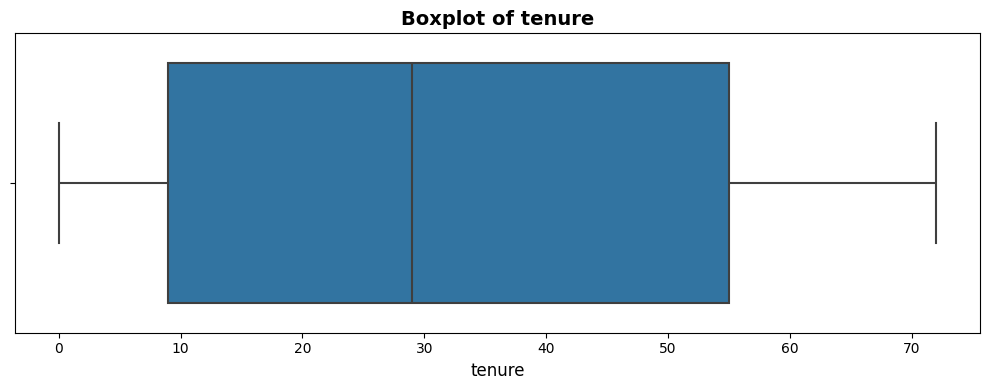

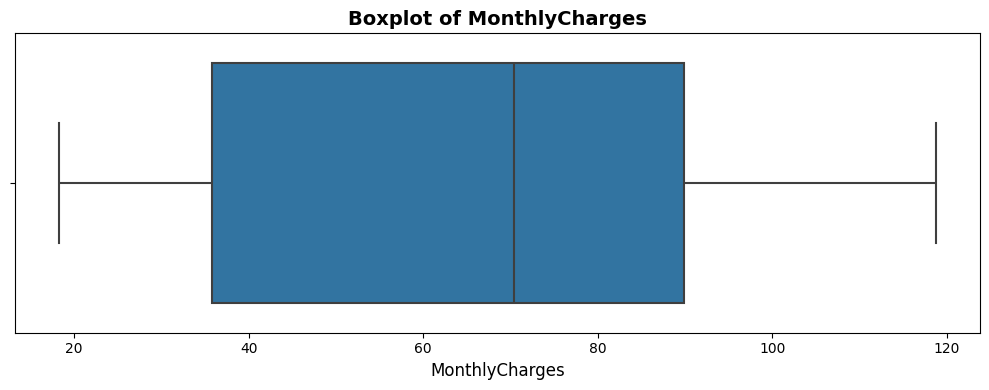

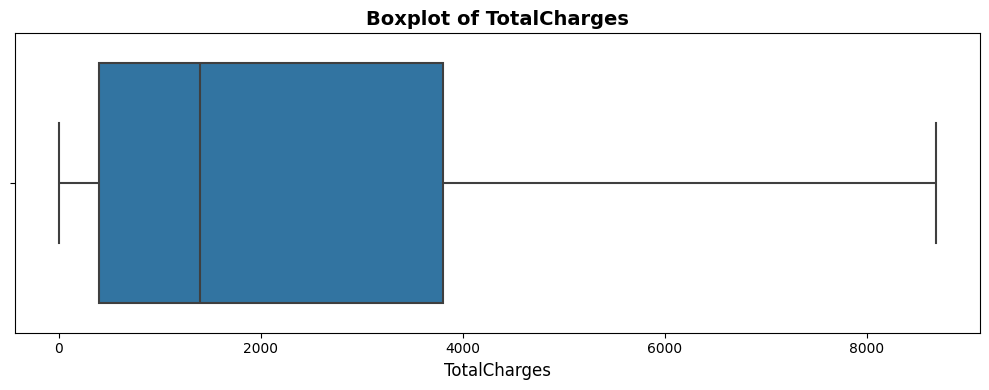

In [107]:

numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in numerical_cols:

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[col],
        linewidth=1.5
    )

    plt.title(
        f"Boxplot of {col}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(col, fontsize=12)

    plt.tight_layout()
    plt.show()

No outliers 

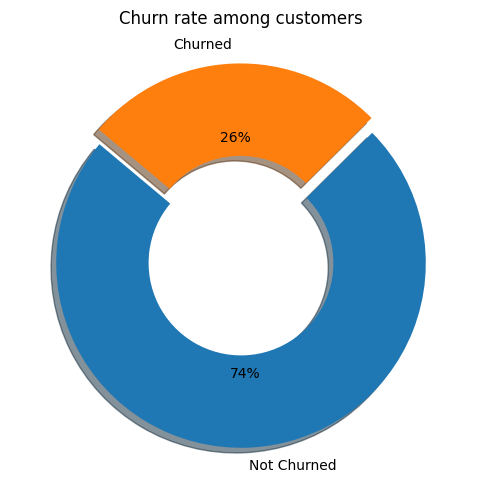

In [108]:
import matplotlib.pyplot as plt

counts = df["Churn"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    counts,
    labels=["Not Churned", "Churned"],
    autopct="%1.0f%%",
    explode=(0, 0.08),
    startangle=140,
    wedgeprops={"width": 0.5},
    shadow=True
)

plt.title("Churn rate among customers")

plt.show()

Observation
- Churn class represents approximately 27% of customers.
- Dataset is moderately imbalanced.
- F1 score should be preferred over accuracy.
- Stratified train-test split will be used.

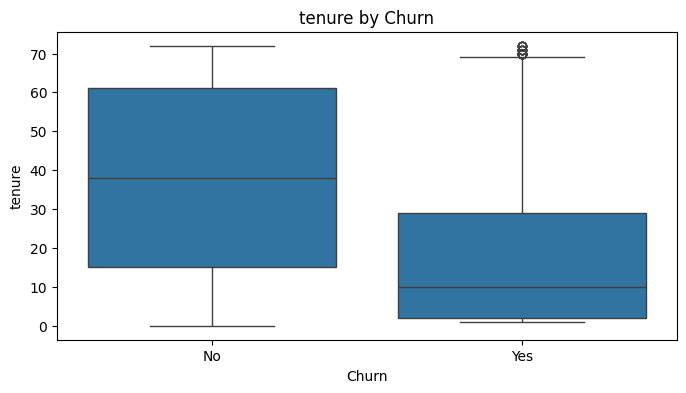

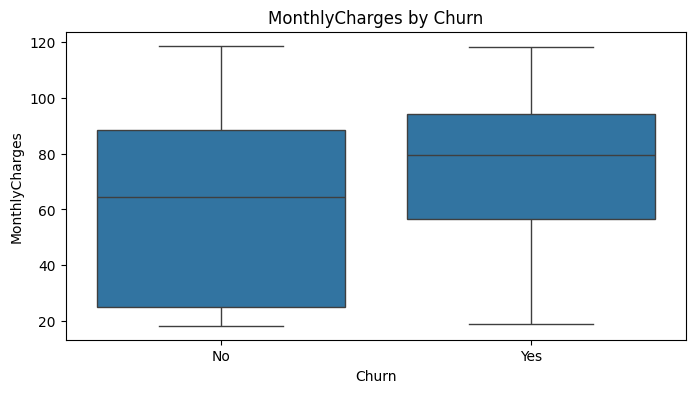

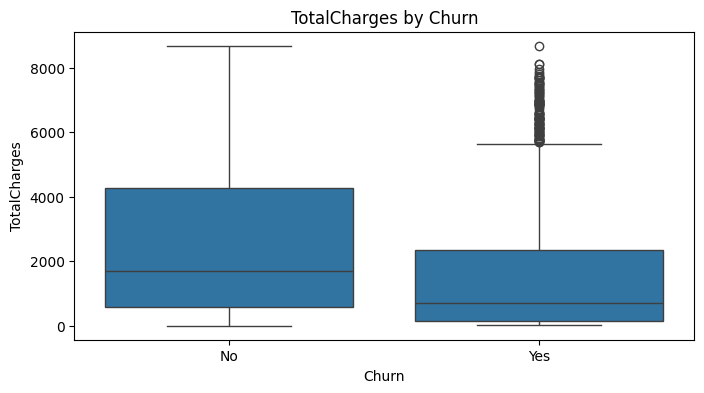

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x="Churn",
        y=col
    )

    plt.title(f"{col} by Churn")
    plt.show()

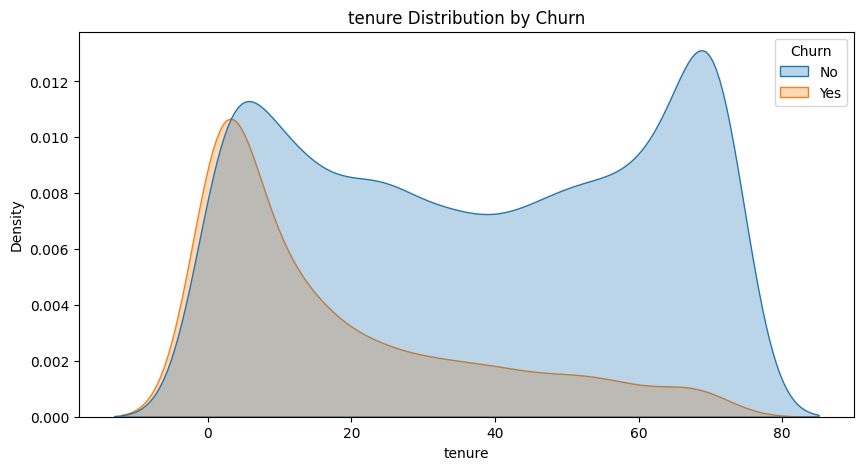

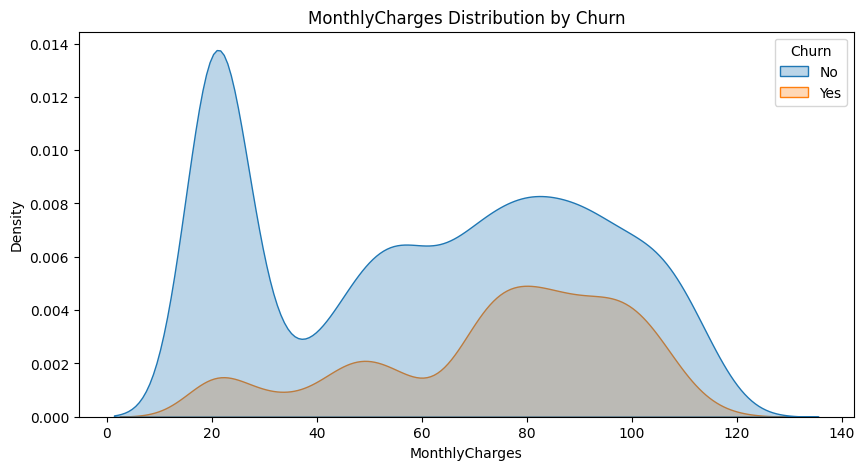

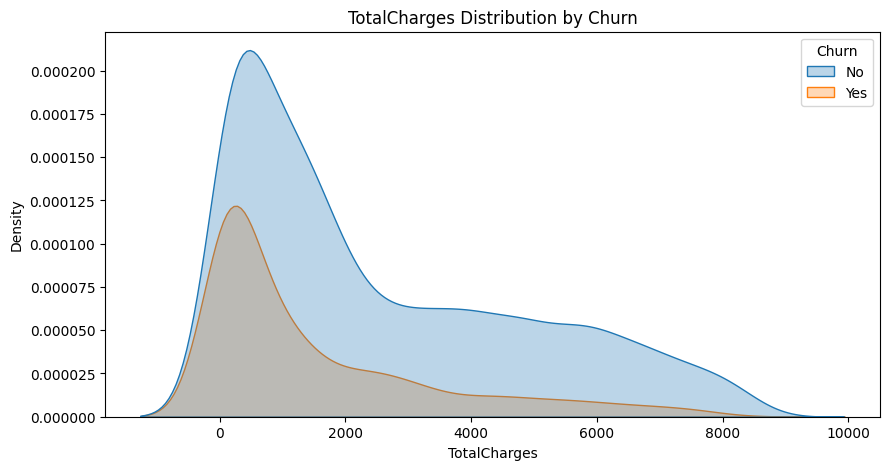

In [110]:
for col in numerical_cols:

    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        data=df,
        x=col,
        hue="Churn",
        fill=True,
        alpha=0.3
    )

    plt.title(f"{col} Distribution by Churn")
    plt.show()

observations

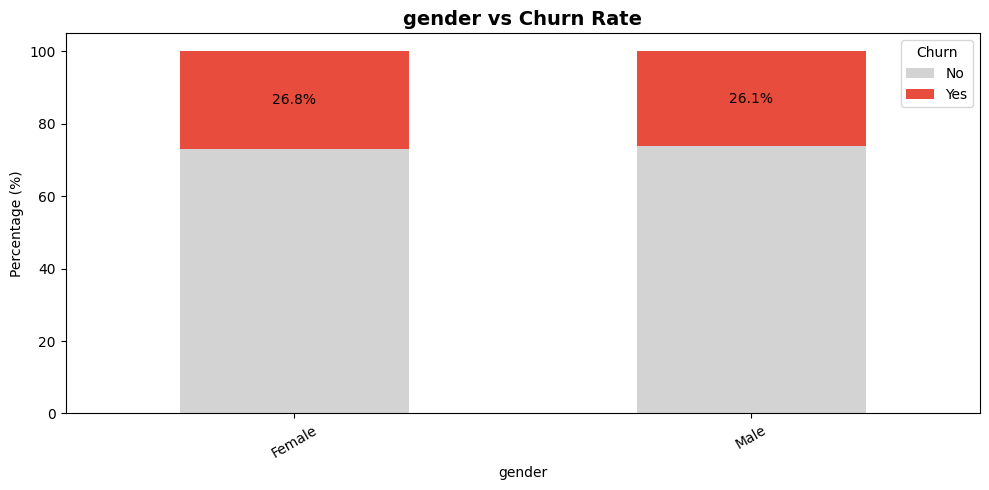

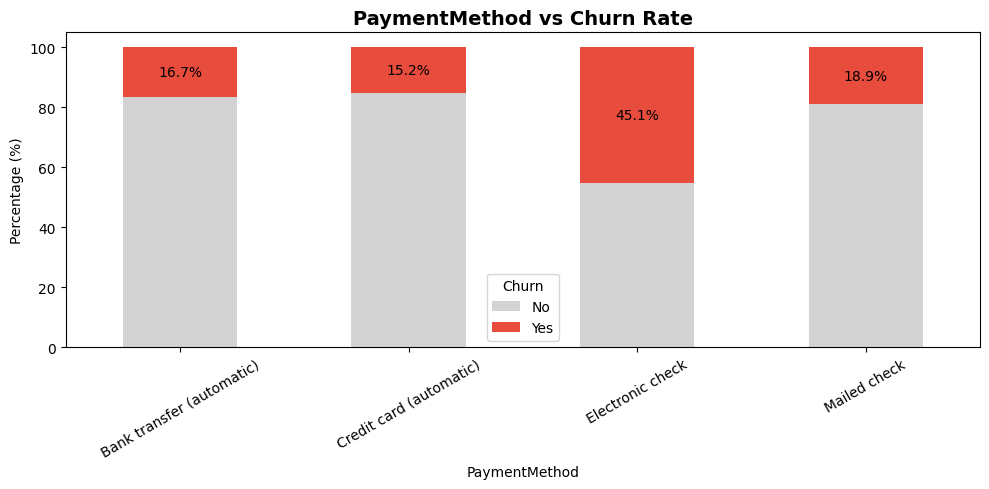

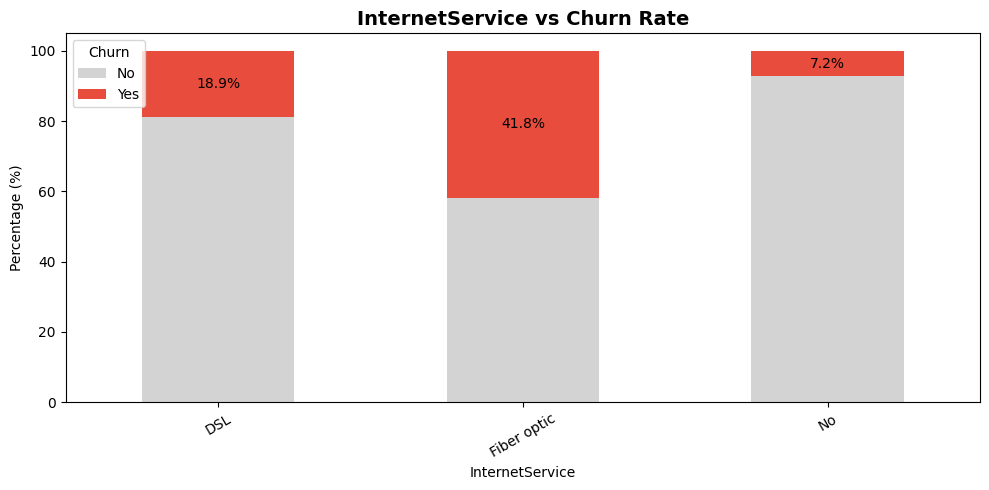

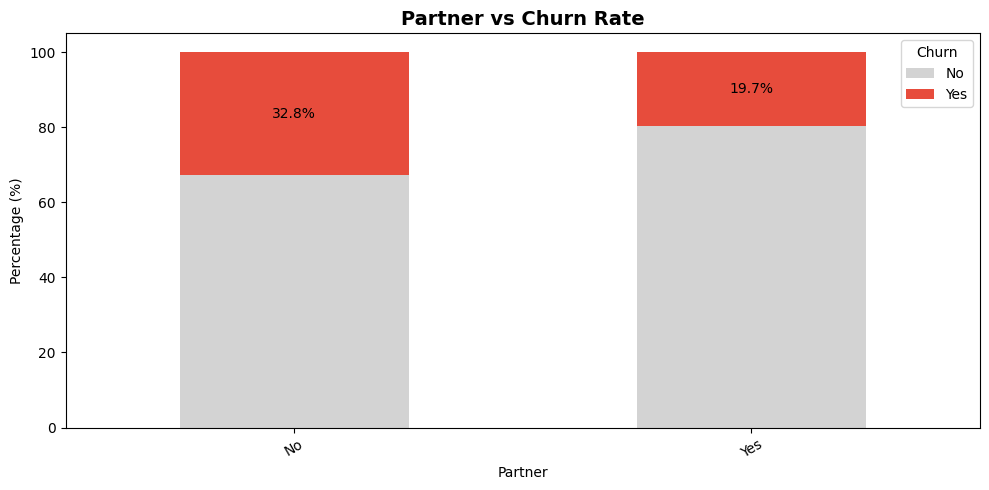

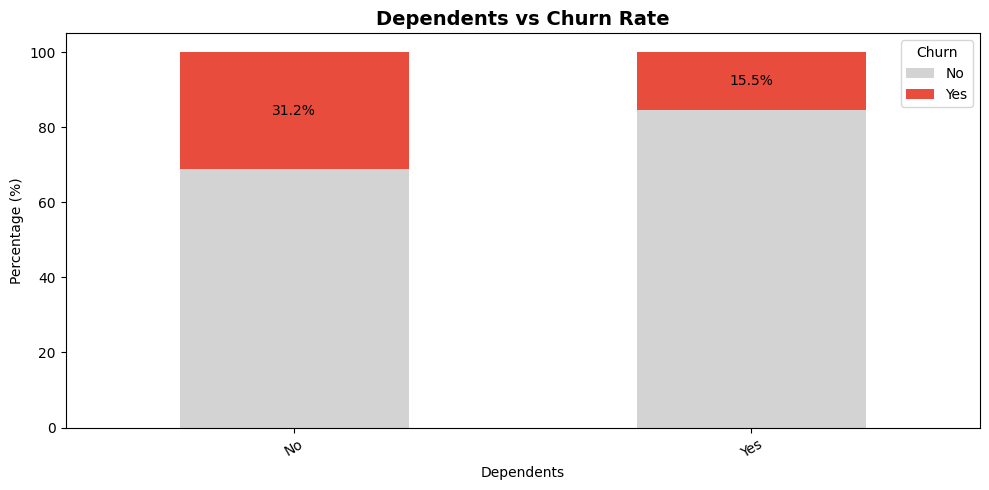

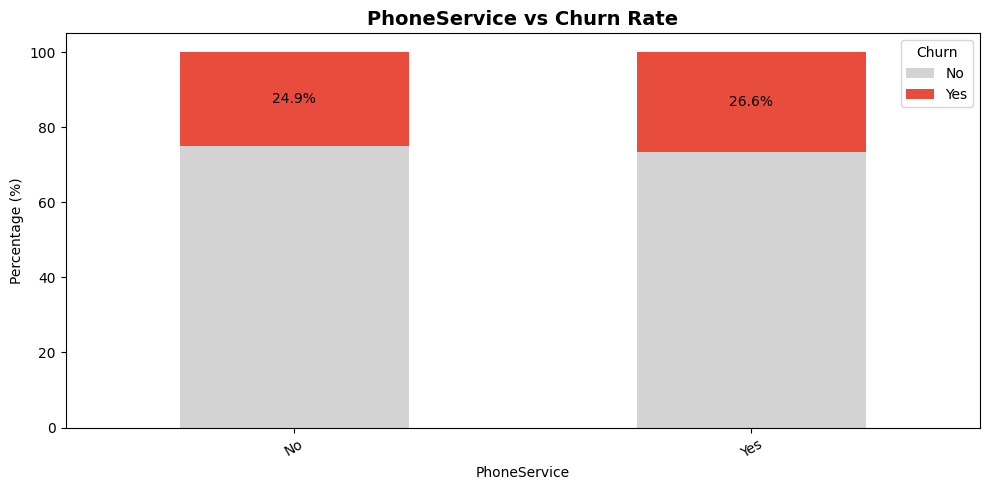

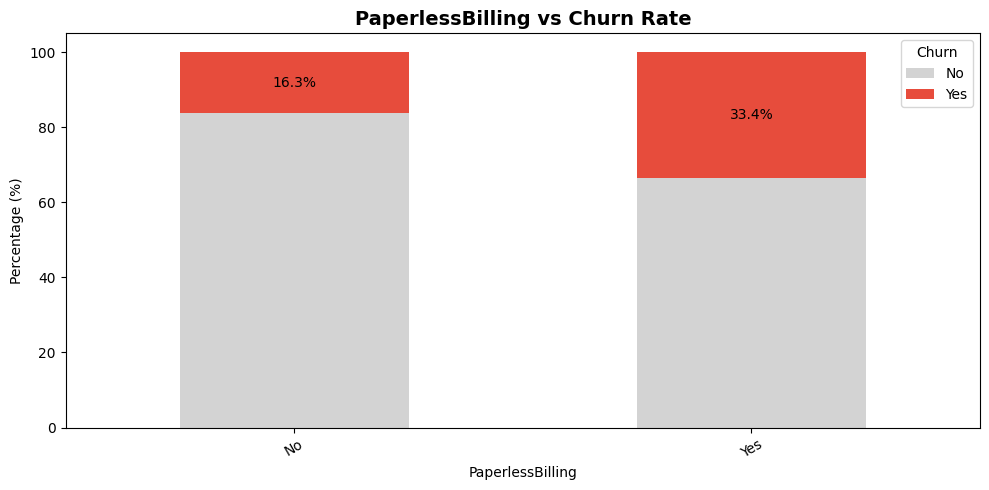

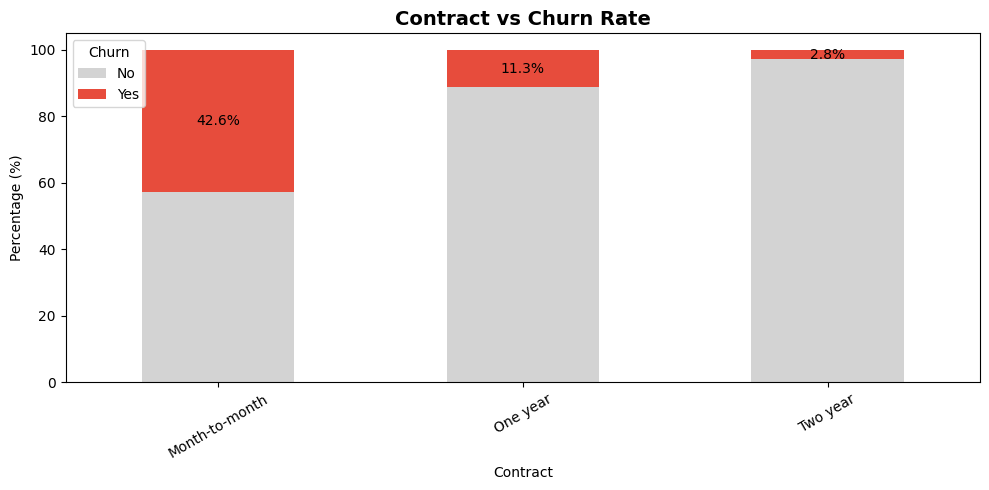

In [111]:
cat_cols = [
    'gender',
    'PaymentMethod', 
    "InternetService", 
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    "Contract"
]


def categorical_vs_churn(cat_cols):

    for col in cat_cols:

        churn_rate = pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        ) * 100

        ax = churn_rate.plot(
            kind="bar",
            stacked=True,
            figsize=(10, 5),
            color=["#D3D3D3", "#E74C3C"]
        )

        yes_container = ax.containers[
            list(churn_rate.columns).index("Yes")
        ]

        ax.bar_label(
            yes_container,
            fmt="%.1f%%",
            label_type="center"
)

        plt.title(
            f"{col} vs Churn Rate",
            fontsize=14,
            fontweight="bold"
        )

        plt.ylabel("Percentage (%)")
        plt.xlabel(col)

        plt.xticks(rotation=30)

        plt.tight_layout()
        plt.show()

categorical_vs_churn(cat_cols)

some crucial pre-processing on data

In [113]:
df["SeniorCitizen"] = df["SeniorCitizen"].astype(bool)

In [114]:
df["SeniorCitizen"]

,SeniorCitizen
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,True


In [115]:
internet_services = [
    'OnlineBackup',
    'OnlineSecurity',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]


for col in internet_services:
     df[col] = df[col].replace({"No internet service" : "No"})
    

In [ ]:

obj_to_bool_cols = [ # using mapping
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn' ,
     *internet_services ]


for col in obj_to_bool_cols:
    df[col] = (df[col].map({"No": 0, "Yes": 1}).astype(bool))




In [119]:
# searching for hidden Nulls 
for column in df.columns:
    print(f"column name: {column}, Type : {df[column].dtype}")
    print(df[column].value_counts(dropna = False))
    print("------------------------")

column name: gender, Type : object
gender
Male      3541
Female    3480
Name: count, dtype: int64
------------------------
column name: SeniorCitizen, Type : bool
SeniorCitizen
False    5880
True     1141
Name: count, dtype: int64
------------------------
column name: Partner, Type : bool
Partner
False    3619
True     3402
Name: count, dtype: int64
------------------------
column name: Dependents, Type : bool
Dependents
False    4911
True     2110
Name: count, dtype: int64
------------------------
column name: tenure, Type : int64
tenure
1     591
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
------------------------
column name: PhoneService, Type : bool
PhoneService
True     6339
False     682
Name: count, dtype: int64
------------------------
column name: MultipleLines, Type : object
MultipleLines
No                  3368
Yes                 2971
No phone service     682
Name: count, dtype: 

/tmp/ipykernel_8609/3500194864.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


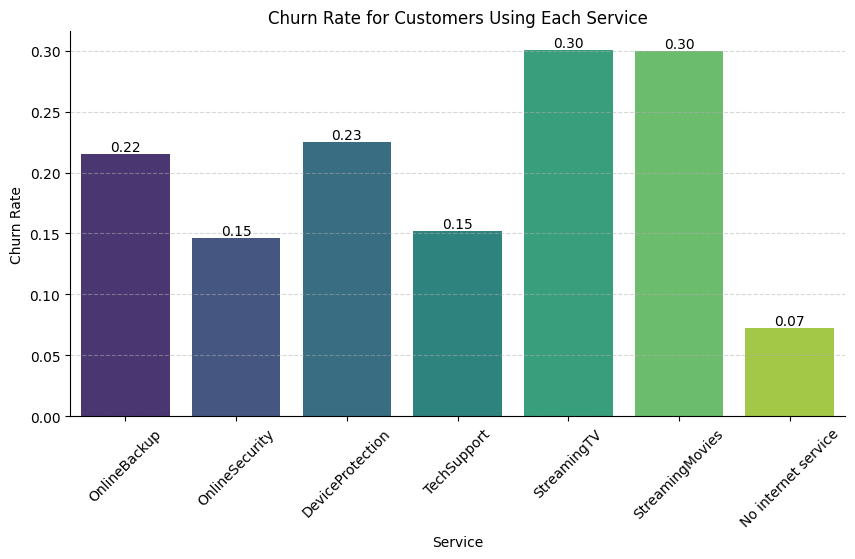

In [120]:


churn_rates = []

for col in internet_services:
    rate = df.loc[df[col] == True ,'Churn'].mean()
    churn_rates.append(rate)

churn_rates.append(df[df["InternetService"] == "No"]["Churn"].mean())
internet_services.append("No internet service")

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=internet_services,
    y=churn_rates,
    palette="viridis",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()


ax.set_title("Churn Rate for Customers Using Each Service")
ax.set_xlabel("Service")
ax.set_ylabel("Churn Rate")

plt.xticks(rotation=45)

plt.show()

<Axes: >

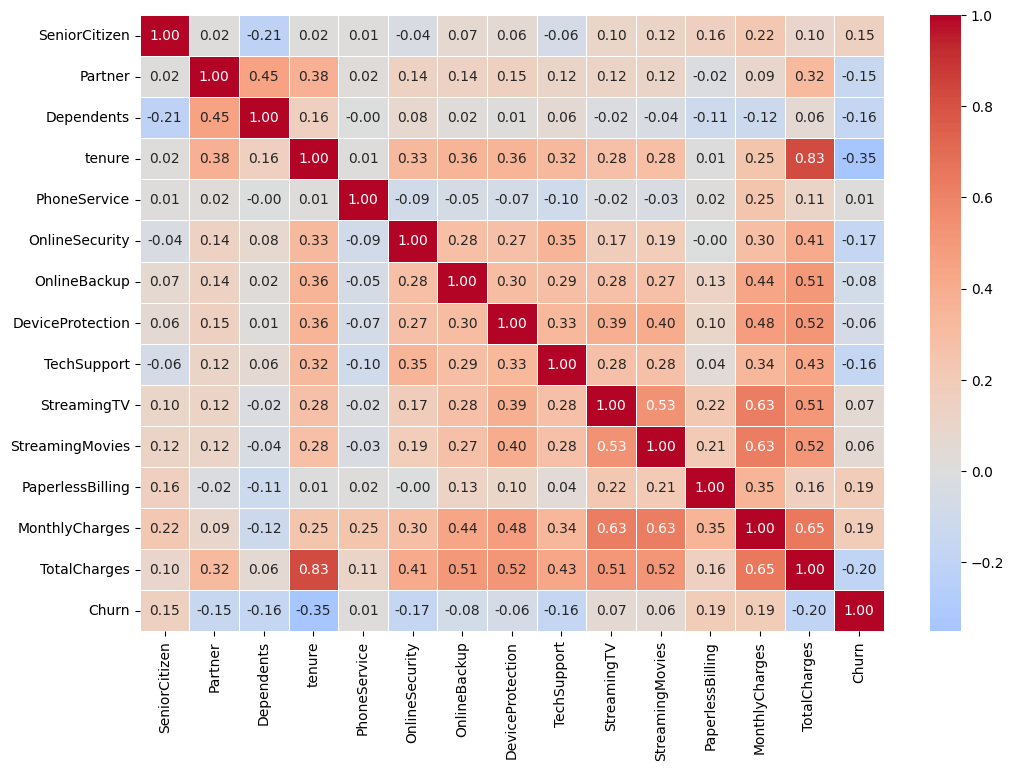

In [124]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize= (12, 8))
sns.heatmap(
    corr_matrix, 
    annot = True, 
    fmt = ".2f", 
    cmap = "coolwarm", 
    center = 0, 
    linewidth = 0.5
)

<div style="background-color:#f5f5f5; padding:20px; border-radius:12px">

## <span style="color:#673AB7">📊 Customer Churn EDA Insights</span>

---

### <span style="color:#F44336">🔴 Total Charges</span>

<span style="color:#555">
The <b>TotalCharges</b> distribution contains noticeable outliers.
A small group of customers accumulated exceptionally high total charges compared to the majority of customers.
</span>

<ul style="color:#555">
<li>Distribution is right-skewed</li>
<li>Extreme values may influence statistical summaries such as the mean</li>
<li>Outliers should be investigated before modeling</li>
</ul>

---

### <span style="color:#FF9800">🟠 Monthly Charges</span>

<span style="color:#555">
Customer churn behavior changes significantly with increasing monthly charges.
</span>

<ul style="color:#555">
<li>Customers paying less than approximately <b>$30</b> show relatively lower churn rates</li>
<li>After the <b>$30</b> threshold, churn frequency increases noticeably</li>
<li>Higher monthly costs appear to increase the probability of customer departure</li>
</ul>

<span style="color:#555">
This suggests that pricing may be an important factor affecting customer retention.
</span>

---

### <span style="color:#4CAF50">🟢 Tenure</span>

<span style="color:#555">
Tenure shows one of the strongest relationships with churn.
</span>

<ul style="color:#555">
<li>New customers exhibit the highest churn rates</li>
<li>A large proportion of churn occurs during the early stages of the customer lifecycle</li>
<li>As customer tenure increases, churn probability consistently decreases</li>
<li>Long-term customers tend to be more loyal and stable</li>
</ul>

<span style="color:#555">
This indicates that the first months of the customer journey are critical for retention efforts.
</span>

---

### <span style="color:#2196F3">🔵 Business Interpretation</span>

<ul style="color:#555">
<li>Focus retention campaigns on newly acquired customers</li>
<li>Investigate reasons behind churn among customers with higher monthly charges</li>
<li>Analyze outliers in TotalCharges to determine whether they represent premium customers or data anomalies</li>
<li>Improve onboarding and customer engagement during the early tenure period</li>
</ul>

</div>

insights for nomial cols

<div style="background-color:#f5f5f5; padding:20px; border-radius:12px">

## <span style="color:#673AB7">📊 Customer Churn EDA Insights — Nominal Features</span>

---

### <span style="color:#F44336">🔴 Contract Type</span>

<span style="color:#555">
Customers with <b>Month-to-Month</b> contracts exhibit significantly higher churn rates than customers with longer-term contracts.
</span>

<ul style="color:#555">
<li>Highest churn observed among Month-to-Month customers</li>
<li>Churn decreases as contract duration increases</li>
<li>Contract commitment appears strongly related to retention</li>
</ul>

---

### <span style="color:#FF9800">🟠 Internet Service</span>

<span style="color:#555">
<b>Fiber Optic</b> customers show noticeably higher churn rates than other internet service groups.
</span>

<ul style="color:#555">
<li>Fiber Optic represents a higher-risk customer segment</li>
<li>Service type appears associated with churn behavior</li>
</ul>

---

### <span style="color:#4CAF50">🟢 Payment Method</span>

<span style="color:#555">
Customers using <b>Electronic Check</b> have the highest churn rate among payment methods.
</span>

<ul style="color:#555">
<li>Electronic Check users churn considerably more often</li>
<li>Payment behavior may indicate churn risk</li>
</ul>

---

### <span style="color:#9C27B0">🟣 Household Characteristics</span>

<span style="color:#555">
Customers without a <b>Partner</b> or <b>Dependents</b> exhibit higher churn rates.
</span>

<ul style="color:#555">
<li>Customers with family responsibilities tend to be more stable</li>
<li>Household composition appears related to retention</li>
</ul>

---

### <span style="color:#3F51B5">🔵 Paperless Billing</span>

<span style="color:#555">
Customers enrolled in <b>Paperless Billing</b> show higher churn rates than those using traditional billing.
</span>

<ul style="color:#555">
<li>Paperless Billing customers are more likely to churn</li>
<li>Billing preference may be a useful churn indicator</li>
</ul>

---

### <span style="color:#2196F3">🔵 Business Interpretation</span>

<ul style="color:#555">
<li>Contract type is one of the strongest indicators of churn risk</li>
<li>Fiber Optic and Electronic Check customers form high-risk segments</li>
<li>Customers without partners or dependents churn more frequently</li>
<li>Paperless Billing is associated with elevated churn rates</li>
<li>These features should be prioritized during churn modeling</li>
</ul>

</div>

In [131]:
from pathlib import Path

file_path = r"Data\Preprocessed\churn_cleaned.csv"

if not Path(file_path).exists():
    df.to_csv(file_path, index=False)

In [133]:
from pathlib import Path

path = Path("Data/processed/churn_cleaned.csv")

path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(path, index=False)